<h1 style="color:black; font-weight:bold; text-align:center;">
Exoplanet Anomaly Detection Project
</h1>

<h3 style="color:black; font-weight:bold; text-align:center;">

</h3>

<hr>

<p style="color:black; font-weight:bold;">
This notebook explores the detection of <b>anomalous exoplanets</b> using 
machine learning techniques, specifically the <b>Isolation Forest algorithm</b>.  
The dataset used is the <b>All Exoplanets 2021</b> catalog, which includes 
planetary, stellar, and orbital parameters.  
</p>

<p style="color:black; font-weight:bold;">
The objective is to identify exoplanets with <b>unusual or extreme physical properties</b> 
that may represent rare planetary systems or data inconsistencies.
</p>

<hr>

<p style="color:black; font-weight:bold; text-align:center;">
Sadika Islam  
<br>
Class: T.Y.B.Sc (Physics)  
<br>
Roll: 234701
</p>


In [1]:
!pip install pandas numpy scikit-learn matplotlib requests astropy lightkurve==2.* umap-learn


  Obtaining dependency information for lightkurve==2.* from https://files.pythonhosted.org/packages/a8/a6/508a3798fc1c2e28b289880e92ec020d14edd3b58d20632ed11ab667b921/lightkurve-2.5.1-py3-none-any.whl.metadata
  Obtaining dependency information for umap-learn from https://files.pythonhosted.org/packages/6b/b1/c24deeda9baf1fd491aaad941ed89e0fed6c583a117fd7b79e0a33a1e6c0/umap_learn-0.5.9.post2-py3-none-any.whl.metadata
  Obtaining dependency information for astroquery>=0.3.10 from https://files.pythonhosted.org/packages/73/8c/64ac07bf58f14d861127d8583122e10686e23161cc9e874b979a35810065/astroquery-0.4.10-py3-none-any.whl.metadata
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/41.2 kB ? eta -:--:--
     ---------------------------------------- 41.2/41.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Obtaini

In [2]:
!pip install lightkurve==2.* astroquery


In [3]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactorww
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt


In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv("all_exoplanets_2021.csv")

# Show the shape and first few rows
print("Shape:", data.shape)
data.head()


Shape: (4575, 23)


,No.,Planet Name,Planet Host,Num Stars,Num Planets,Discovery Method,Discovery Year,Discovery Facility,Orbital Period Days,Orbit Semi-Major Axis,...,Equilibrium Temperature,Spectral Type,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Metallicity Ratio,Stellar Surface Gravity,Distance,Gaia Magnitude
0,1,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,326.03000,1.29,...,NaN,G8 III,4742.0,19.00,2.70,-0.35,[Fe/H],2.31,93.1846,4.44038
1,2,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,516.21997,1.53,...,NaN,NaN,4213.0,29.79,2.78,-0.02,[Fe/H],1.93,125.3210,4.56216
2,3,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,185.84000,0.83,...,NaN,K0 III,4813.0,11.00,2.20,-0.24,[Fe/H],2.63,75.4392,4.91781
3,4,14 Her b,14 Her,1,2,Radial Velocity,2002,W. M. Keck Observatory,1773.40002,2.93,...,NaN,NaN,5338.0,0.93,0.90,0.41,[Fe/H],4.45,17.9323,6.38300
4,5,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996,Multiple Observatories,798.50000,1.66,...,NaN,NaN,5750.0,1.13,1.08,0.06,[Fe/H],4.36,21.1397,6.06428


In [3]:
# Keep only numeric columns and remove missing values
numeric_data = data.select_dtypes(include=['float64', 'int64']).dropna()

print("Cleaned data shape:", numeric_data.shape)
numeric_data.head()


Cleaned data shape: (154, 17)


,No.,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude
159,160,1,1,2018,3650.000000,4.5000,4131.79,0.000,0.19,183.0,4898.0,2.70,0.90,-0.23,3.52,551.8860,12.1722
160,161,1,3,2020,3.595100,0.0470,8.75,0.060,1037.00,1616.0,5430.0,1.71,1.05,0.20,3.99,321.2960,11.4019
161,162,1,3,2020,15.624000,0.1300,14.67,0.070,160.00,990.0,5430.0,1.71,1.05,0.20,3.99,321.2960,11.4019
162,163,1,3,2020,35.747000,0.2200,10.18,0.150,53.00,752.0,5430.0,1.71,1.05,0.20,3.99,321.2960,11.4019
175,176,1,1,2009,1.580404,0.0149,8.17,0.063,21.00,596.0,3250.0,0.21,0.18,0.29,5.03,14.6427,13.0089


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Scale the numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_data)

# Apply Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_scaled)

# Get anomaly labels and scores
numeric_data["Anomaly_Label"] = iso.predict(X_scaled)   # 1 = normal, -1 = anomaly
numeric_data["Anomaly_Score"] = iso.decision_function(X_scaled)

print(numeric_data["Anomaly_Label"].value_counts())
numeric_data.head()


Anomaly_Label
 1    146
-1      8
Name: count, dtype: int64


,No.,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Anomaly_Label,Anomaly_Score
159,160,1,1,2018,3650.000000,4.5000,4131.79,0.000,0.19,183.0,4898.0,2.70,0.90,-0.23,3.52,551.8860,12.1722,-1,-0.101459
160,161,1,3,2020,3.595100,0.0470,8.75,0.060,1037.00,1616.0,5430.0,1.71,1.05,0.20,3.99,321.2960,11.4019,1,0.115974
161,162,1,3,2020,15.624000,0.1300,14.67,0.070,160.00,990.0,5430.0,1.71,1.05,0.20,3.99,321.2960,11.4019,1,0.126014
162,163,1,3,2020,35.747000,0.2200,10.18,0.150,53.00,752.0,5430.0,1.71,1.05,0.20,3.99,321.2960,11.4019,1,0.105298
175,176,1,1,2009,1.580404,0.0149,8.17,0.063,21.00,596.0,3250.0,0.21,0.18,0.29,5.03,14.6427,13.0089,1,0.020585


In [6]:
numeric_data.to_csv("exoplanet_anomalies_detected.csv", index=False)
print("Results saved as 'exoplanet_anomalies_detected.csv'")


Results saved as 'exoplanet_anomalies_detected.csv'


In [7]:
anomalies = numeric_data[numeric_data["Anomaly_Label"] == -1]
print("Number of anomalies detected:", len(anomalies))
anomalies.head(10)


Number of anomalies detected: 8


,No.,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Anomaly_Label,Anomaly_Score
159,160,1,1,2018,3650.000000,4.50000,4131.79000,0.0000,0.19,183.0,4898.0,2.70,0.90,-0.230,3.52,551.8860,12.17220,-1,-0.101459
278,279,1,1,2021,1.744579,0.03380,6261.21962,0.0000,4650.00,2300.0,7000.0,1.56,1.68,0.350,4.27,655.0130,12.22280,-1,-0.013824
408,409,1,2,2018,1422.000000,2.50400,4036.44100,0.0830,0.16,176.0,5670.0,1.04,1.04,0.180,4.42,642.8840,13.78540,-1,-0.009603
421,422,1,1,2019,1.888238,0.03632,4100.00700,0.1800,9110.00,2730.0,7930.0,1.88,1.78,0.041,4.17,1458.8300,12.58600,-1,-0.051662
496,497,1,1,2021,3700.000000,5.00000,2634.79749,0.4870,0.06,145.0,5957.0,1.21,1.18,0.340,4.15,87.6437,8.18736,-1,-0.054895
1557,1558,2,1,2017,1.481124,0.03462,915.35040,0.0000,44900.00,4050.0,10170.0,2.36,2.52,-0.030,4.09,204.4550,7.57675,-1,-0.111190
2557,2558,1,1,2013,988.881130,2.02600,1318.98789,0.9210,0.34,254.0,5745.0,1.70,1.13,0.196,4.03,835.4550,13.25140,-1,-0.063849
4563,4564,1,2,1997,39.845800,0.21960,332.10000,0.0373,34.70,614.0,5627.0,1.36,0.89,-0.310,4.12,17.4671,5.24167,-1,-0.013520


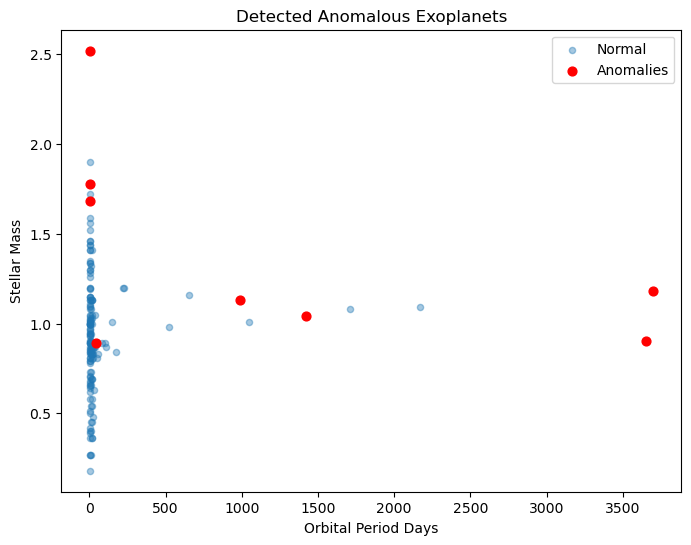

In [8]:
import matplotlib.pyplot as plt

x = "Orbital Period Days"
y = "Stellar Mass"

plt.figure(figsize=(8,6))
plt.scatter(numeric_data[x], numeric_data[y], s=20, alpha=0.4, label="Normal")
plt.scatter(anomalies[x], anomalies[y], s=40, color="red", label="Anomalies")
plt.xlabel(x)
plt.ylabel(y)
plt.title("Detected Anomalous Exoplanets")
plt.legend()
plt.show()


In [9]:
anomalies.to_csv("detected_anomalous_exoplanets.csv", index=False)
print("Saved anomalies as 'detected_anomalous_exoplanets.csv'")


Saved anomalies as 'detected_anomalous_exoplanets.csv'


In [10]:
anomalies.describe()


,No.,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Anomaly_Label,Anomaly_Score
count,8.000000,8.000000,8.00000,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.0,8.000000
mean,1305.875000,1.125000,1.25000,2015.50000,1225.730109,1.794293,2966.336675,0.213537,7336.931250,1306.500000,6624.625000,1.726250,1.390000,0.067125,4.096250,556.704225,10.627948,-1.0,-0.052500
std,1551.688614,0.353553,0.46291,7.89213,1603.333669,2.067458,2021.819921,0.329784,15537.886062,1512.654431,1712.218939,0.569886,0.565357,0.246243,0.261967,469.577570,3.159849,0.0,0.039338
min,160.000000,1.000000,1.00000,1997.00000,1.481124,0.033800,332.100000,0.000000,0.060000,145.000000,4898.000000,1.040000,0.890000,-0.310000,3.520000,17.467100,5.241670,-1.0,-0.111190
25%,376.500000,1.000000,1.00000,2016.00000,1.852323,0.035895,1218.078518,0.000000,0.182500,181.250000,5659.250000,1.322500,1.005000,-0.080000,4.075000,175.252175,8.034707,-1.0,-0.073252
50%,459.500000,1.000000,1.00000,2018.00000,514.363465,1.122800,3335.619245,0.060150,17.520000,434.000000,5851.000000,1.630000,1.155000,0.110500,4.135000,597.385000,12.197500,-1.0,-0.053279
75%,1808.000000,1.000000,1.25000,2019.50000,1979.000000,3.003000,4107.952750,0.256750,5765.000000,2407.500000,7232.500000,2.000000,1.705000,0.232000,4.195000,700.123500,12.752350,-1.0,-0.013748
max,4564.000000,2.000000,2.00000,2021.00000,3700.000000,5.000000,6261.219620,0.921000,44900.000000,4050.000000,10170.000000,2.700000,2.520000,0.350000,4.420000,1458.830000,13.785400,-1.0,-0.009603


In [11]:
numeric_data.describe()


,No.,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Anomaly_Label,Anomaly_Score
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,2094.675325,1.168831,1.642857,2018.610390,117.232765,0.251438,409.568133,0.092057,873.965065,1037.974026,5297.455195,1.076623,0.951429,0.069013,4.409481,287.157404,11.055862,0.896104,0.117045
std,1710.992468,0.409131,1.135745,2.929034,495.339908,0.710118,874.207797,0.137041,3740.578709,593.674070,1028.702844,0.496553,0.338177,0.196128,0.269596,441.881318,2.475069,0.445292,0.057139
min,160.000000,1.000000,1.000000,1997.000000,0.768448,0.012110,0.290130,0.000000,0.060000,145.000000,3250.000000,0.210000,0.180000,-0.500000,3.520000,5.580570,5.240200,-1.000000,-0.111190
25%,420.500000,1.000000,1.000000,2018.000000,3.052601,0.038845,9.705000,0.000000,24.632500,600.500000,4699.000000,0.760000,0.802500,-0.038250,4.250000,61.044900,9.910360,1.000000,0.087910
50%,1380.500000,1.000000,1.000000,2019.000000,4.820051,0.054950,59.195785,0.057000,143.800000,958.500000,5520.000000,0.975000,0.935000,0.110000,4.425000,154.961000,11.626500,1.000000,0.129739
75%,4196.750000,1.000000,2.000000,2020.000000,15.595250,0.117425,300.985010,0.126250,733.867500,1407.750000,5843.750000,1.340000,1.130000,0.200000,4.580000,367.937000,12.557850,1.000000,0.159045
max,4565.000000,3.000000,6.000000,2021.000000,3700.000000,5.000000,6261.219620,0.921000,44900.000000,4050.000000,10170.000000,2.700000,2.520000,0.432000,5.030000,4483.050000,19.879000,1.000000,0.193866


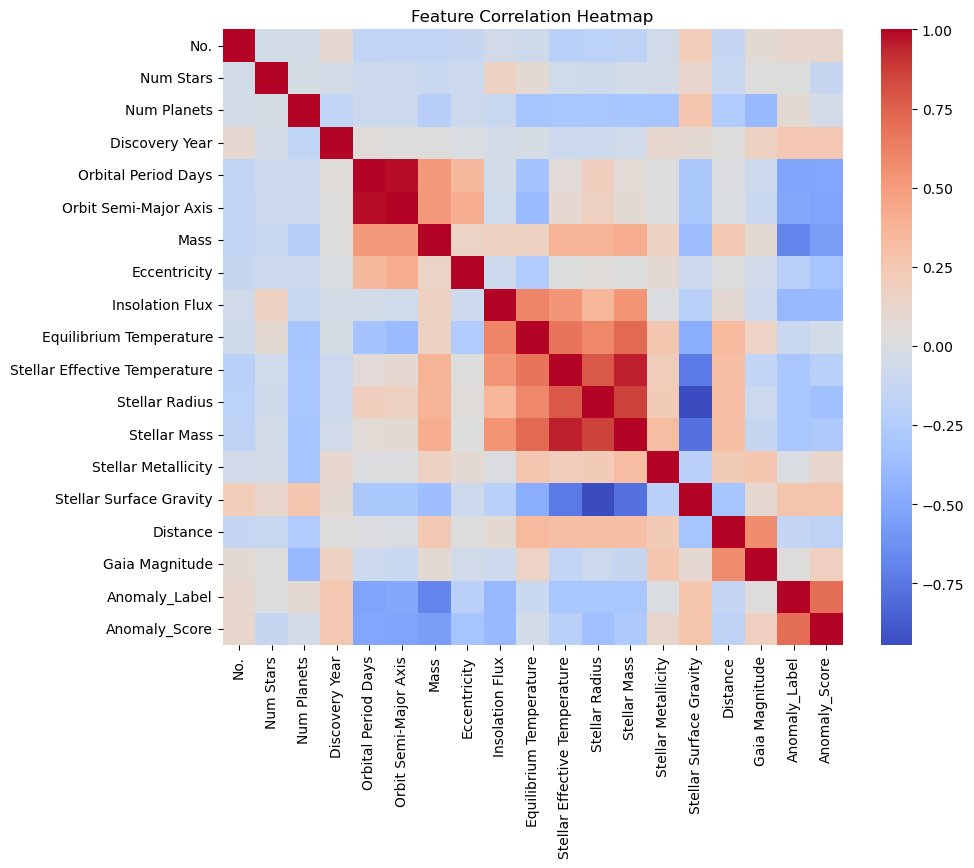

In [12]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


# Exoplanet Anomaly Detection-Summary

### Dataset:
- Source: All exoplanets discovered till 2021 dataset from Kaggle  
- Total entries: 4575  
- After cleaning (numeric columns only): 154 usable entries

### Objective:
To identify **anomalous exoplanets** — planets with unusual or extreme physical properties — using **Isolation Forest** anomaly detection.

### Method:
1. Cleaned dataset (numeric values only, dropped NaNs)
2. Scaled data using `StandardScaler`
3. Applied `IsolationForest` (contamination = 0.05)
4. Generated anomaly labels (`Anomaly_Label = -1`) and scores
5. Visualized results using:
   - Scatter plots for normal vs anomalous planets  
   - Correlation heatmap of features

### Key Findings:
- 8 exoplanets were flagged as anomalies out of 154 total.
- Strong positive correlations found among:
  - *Stellar Radius*, *Stellar Mass*, and *Effective Temperature*
- Negative correlation between:
  - *Stellar Radius* and *Surface Gravity*
- Anomalies mostly correspond to planets with **extreme orbital periods or stellar masses**.

### Output:
- `exoplanet_anomalies_detected.csv` → all data with anomaly scores  
- `detected_anomalous_exoplanets.csv` → only anomalies  
- `heatmap` and scatter plots for visualization

### Conclusion:
The Isolation Forest method successfully identified potential **rare or unusual exoplanetary systems**.  
These may represent outliers worth further astrophysical investigation or possible data inconsistencies.
